In [ ]:
#task



#แสดงตัวอย่างการทำ Exploratory Data Analysis ด้วยค่ากราฟ อย่างน้อย 3 คอลัมภ์   โดยแสดงด้วย  colab (ทำแล้ว)
#สดงตัวอย่างการทำ Manipulate ด้วยการทำ group by หรือ pivot table อย่างน้อย 1 ตัวอย่าง  โดยแสดงด้วย  colab  (ทำแล้ว)
#แสดงตัวอย่างการทำ data cleaning  อย่างน้อย 3 วิธี  โดยแสดงด้วย  colab (ทำแล้ว)
#เลือก เทคนิค machine learning 1 วิธี เพื่อนำเรียนรู้ข้อมูล และทำนายผล โดยแสดงด้วย  colab (ทำแล้ว)
#ตั้งแต่การเตรียมข้อมูล train, test การสอนโมเดล และการทำนายผลพร้อมแปลผลลัพธ์

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
import scipy.stats as stats
#Preprocessing
from sklearn.preprocessing import LabelEncoder , MinMaxScaler , QuantileTransformer , PowerTransformer
#Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , confusion_matrix
#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# อ่านไฟล์ CSV อีกครั้งเพื่อให้แน่ใจว่า DataFrame อยู่ในสถานะที่ถูกต้อง
df = pd.read_csv('Iris.csv')

# อธิบายข้อมูลเบื้องต้น (Metadata)
print("ข้อมูลชุดนี้คือข้อมูลดอกไม้ชนิด Iris")
print("มี 5 คอลัมน์ ได้แก่ Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm และ Species")
print("โดยข้อมูลนี้ใช้ในการจำแนกชนิดของดอกไม้ 3 สายพันธุ์ ได้แก่ Iris-setosa, Iris-versicolor และ Iris-virginica\n")

# แสดงข้อมูลเบื้องต้นของ dataset
df.info()
display(df.head())
print(f"\nจำนวนแถวทั้งหมด: {df.shape[0]}")
print(f"จำนวนคอลัมน์ทั้งหมด: {df.shape[1]}")

# อธิบายประเภทของข้อมูลแต่ละคอลัมน์
print("\nประเภทของข้อมูล (Data Type Classification):")
data_types = {
    'Id': 'ข้อมูลเชิงปริมาณ (Quantitative - Discrete)',
    'SepalLengthCm': 'ข้อมูลเชิงปริมาณ (Quantitative - Continuous)',
    'SepalWidthCm': 'ข้อมูลเชิงปริมาณ (Quantitative - Continuous)',
    'PetalLengthCm': 'ข้อมูลเชิงปริมาณ (Quantitative - Continuous)',
    'PetalWidthCm': 'ข้อมูลเชิงปริมาณ (Quantitative - Continuous)',
    'Species': 'ข้อมูลเชิงคุณภาพ (Qualitative - Nominal)'
}
for col, dtype in data_types.items():
    print(f"{col}: {dtype}")


ข้อมูลชุดนี้คือข้อมูลดอกไม้ชนิด Iris
มี 5 คอลัมน์ ได้แก่ Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm และ Species
โดยข้อมูลนี้ใช้ในการจำแนกชนิดของดอกไม้ 3 สายพันธุ์ ได้แก่ Iris-setosa, Iris-versicolor และ Iris-virginica

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



จำนวนแถวทั้งหมด: 150
จำนวนคอลัมน์ทั้งหมด: 6

ประเภทของข้อมูล (Data Type Classification):
Id: ข้อมูลเชิงปริมาณ (Quantitative - Discrete)
SepalLengthCm: ข้อมูลเชิงปริมาณ (Quantitative - Continuous)
SepalWidthCm: ข้อมูลเชิงปริมาณ (Quantitative - Continuous)
PetalLengthCm: ข้อมูลเชิงปริมาณ (Quantitative - Continuous)
PetalWidthCm: ข้อมูลเชิงปริมาณ (Quantitative - Continuous)
Species: ข้อมูลเชิงคุณภาพ (Qualitative - Nominal)


## 3. Exploratory Data Analysis (EDA) ด้วยค่าสถิติ

ในส่วนนี้ จะทำการวิเคราะห์ข้อมูลเชิงสำรวจโดยใช้ค่าสถิติพื้นฐานเพื่อทำความเข้าใจลักษณะของข้อมูลในแต่ละคอลัมน์ที่เป็นตัวเลข

In [ ]:
# คอลัมน์ที่เป็นตัวเลขสำหรับ EDA
numeric_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# คำนวณค่าสถิติพรรณนาสำหรับคอลัมน์ที่เลือก
descriptive_stats = df[numeric_cols].describe()

# แสดงผลลัพธ์
print("ค่าสถิติพรรณนาสำหรับคอลัมน์ที่เป็นตัวเลข:")
display(descriptive_stats)

ค่าสถิติพรรณนาสำหรับคอลัมน์ที่เป็นตัวเลข:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


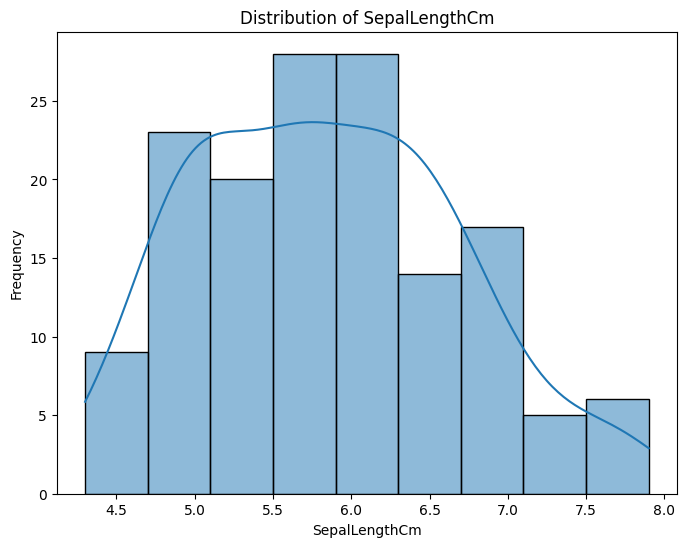

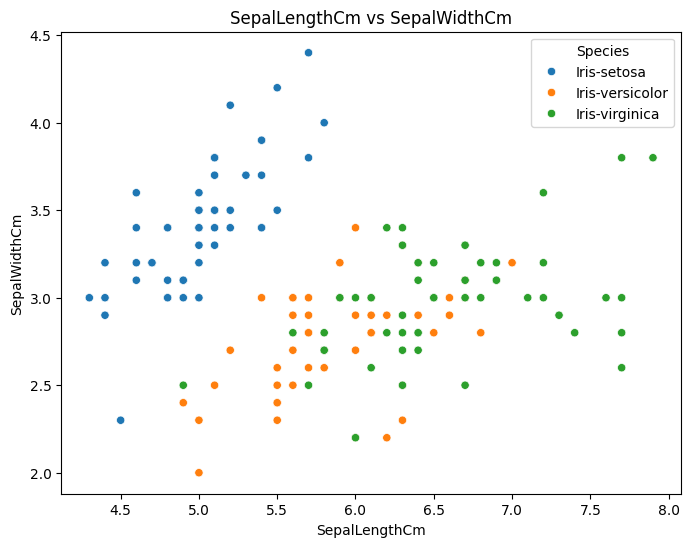

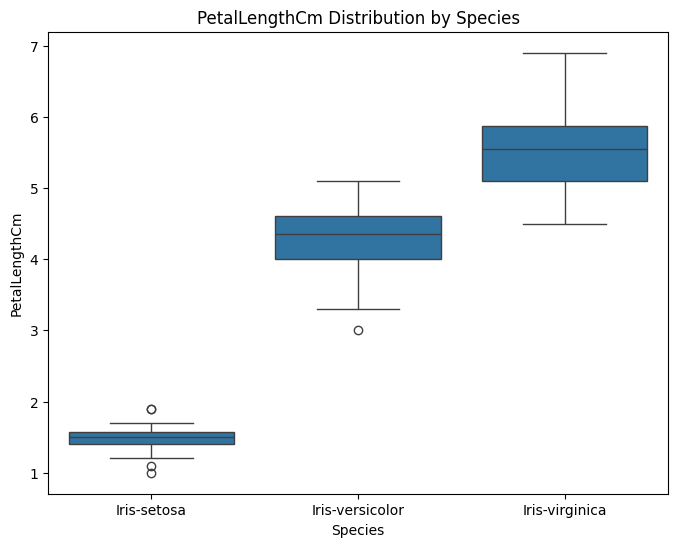

In [ ]:
#   Histogram สำหรับ 'SepalLengthCm'
plt.figure(figsize=(8, 6))
sns.histplot(df['SepalLengthCm'], kde=True)
plt.title('Distribution of SepalLengthCm')
plt.xlabel('SepalLengthCm')
plt.ylabel('Frequency')
plt.show()

# 2. Scatter plot of 'SepalLengthCm' vs 'SepalWidthCm'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=df)
plt.title('SepalLengthCm vs SepalWidthCm')
plt.xlabel('SepalLengthCm')
plt.ylabel('SepalWidthCm')
plt.show()

# 3. Box plot สำหรับ 'PetalLengthCm' grouped by 'Species'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Species', y='PetalLengthCm', data=df)
plt.title('PetalLengthCm Distribution by Species')
plt.xlabel('Species')
plt.ylabel('PetalLengthCm')
plt.show()

In [ ]:
#ทำไว้เฉยๆ เพื่ออันแรก อาจารถามแล้วตอบไม่ได้  อันนี้ อธิบาย ง่ายกว่า
grouped_data = df.groupby('Species')[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].mean()
display(grouped_data)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [ ]:

df_null = df.isnull().sum().sum()
print(df_null)


data_duplicates = df.duplicated().sum()
print(data_duplicates)


df = df.drop_duplicates()


data_duplicates_after_drop = df.duplicated().sum()
print(data_duplicates_after_drop)

0
0
0


**Reasoning**:
The data cleaning steps for checking and removing duplicates have been completed. The next step is to address other data cleaning techniques as requested by the subtask. Based on the available data, a potential cleaning step could be to handle the 'Id' column, which is not useful for analysis and was attempted to be dropped previously.



In [ ]:

# มันมี ไอดีใน csv มาให้ เพื่อไรก็ไม่รู้ เอาออก ก็เอาออก
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# หา q1
Q1 = df['SepalLengthCm'].quantile(0.25)
# หา q2
Q3 = df['SepalLengthCm'].quantile(0.75)

#สูตร iqr เลย
IQR = Q3 - Q1

#หา lower_bound
lower_bound = Q1 - 1.5 * IQR
#หา upper_bound
upper_bound = Q3 + 1.5 * IQR

# หา outliers
outliers_sepal_length = df[(df['SepalLengthCm'] < lower_bound) | (df['SepalLengthCm'] > upper_bound)]

print(len(outliers_sepal_length))
display(outliers_sepal_length)

0


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species


In [ ]:
#เอาคอลัมน์ 'Species' ออกจาก DataFrame
X = df.drop('Species', axis=1)
# เลือกเฉพาะคอลัมน์ 'Species'
y = df['Species']

# เอาแค่ X,Y เลือกเป็น 80:20 สุ่ม 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ใช้ RandomForestClassifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# ทำนายค่า Y
y_pred = model.predict(X_test)



# ความถูกต้องโดยรวมของโมเดล ,ความแม่นยำของโมเดลในแต่ละคลาส ,ความสามารถของโมเดลในการจับตัวอย่างที่เป็นคลาสนั้นจริงๆ, ค่าเฉลี่ยเชิงฮาร์มอนิกของ Precision และ Recall
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000
